## Neural Networks from Scratch: Pure NumPy 🔢


## 1. The Story

You've used TensorFlow and PyTorch. They feel like magic. But what's actually happening under the hood?
"Frameworks are like driving an automatic. Building from scratch is like learning manual — you understand every gear."
Today: No TensorFlow. No PyTorch. Just NumPy, math, and intuition.

Input (2) → Hidden (4, ReLU) → Output (1, Sigmoid)

### Forward pass -

Z = W·X + b        (linear)

A = activation(Z)  (non-linear)

### backward pass -
Error = Predicted - Actual

dW = Error · Input   (how much to adjust weights)

W = W - lr·dW        (update)

In [ ]:
#### LET CODE

In [1]:
import numpy as np

In [3]:
# first activation function -
def relu(x):
    """ReLU: max(0, x)"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU: 1 if x>0, else 0"""
    return (x > 0).astype(float)

def sigmoid(x):
    """Sigmoid: 1/(1+e^-x)"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid: sigmoid(x) * (1 - sigmoid(x))"""
    s = sigmoid(x)
    return s * (1 - s)

In [4]:
# defining neural network class
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly (small values)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        """Forward pass: X → Hidden → Output"""
        # Layer 1
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        # Layer 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2)

        return self.A2

    def backward(self, X, y, learning_rate):
        """Backpropagation: calculate gradients and update weights"""
        m = X.shape[0]  # number of samples

        # Output layer error
        dZ2 = self.A2 - y  # derivative of loss w.r.t Z2
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer error (chain rule)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        # Clip to avoid log(0)
        y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
        loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return np.sum(loss) / m

    def train(self, X, y, epochs=1000, learning_rate=0.1, verbose=True):
        """Full training loop"""
        losses = []

        for epoch in range(epochs):
            # Forward
            output = self.forward(X)

            # Loss
            loss = self.compute_loss(y, output)
            losses.append(loss)

            # Backward
            self.backward(X, y, learning_rate)

            # Print progress
            if verbose and epoch % 100 == 0:
                predictions = (output > 0.5).astype(int)
                accuracy = np.mean(predictions == y)
                print(f"Epoch {epoch}: Loss={loss:.4f}, Accuracy={accuracy:.4f}")

        return losses

In [5]:
# Testing neural network
# XOR problem: classic non-linear problem
# 0 XOR 0 = 0, 0 XOR 1 = 1, 1 XOR 0 = 1, 1 XOR 1 = 0

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])  # XOR output

print(f"\nInput shape: {X.shape}")
print(f"Output shape: {y.shape}")

# Create and train
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)

print("\n--- Training ---")
losses = nn.train(X, y, epochs=1000, learning_rate=0.5)

# Predictions
print("\n--- Predictions ---")
predictions = nn.forward(X)
for i in range(len(X)):
    print(f"Input: {X[i]} → Predicted: {predictions[i][0]:.4f} → Actual: {y[i][0]}")

# Final accuracy
final_pred = (predictions > 0.5).astype(int)
accuracy = np.mean(final_pred == y)
print(f"\nFinal Accuracy: {accuracy*100:.0f}%")


Input shape: (4, 2)
Output shape: (4, 1)

--- Training ---
Epoch 0: Loss=0.6931, Accuracy=0.5000
Epoch 100: Loss=0.5985, Accuracy=0.7500
Epoch 200: Loss=0.4828, Accuracy=0.7500
Epoch 300: Loss=0.4793, Accuracy=0.7500
Epoch 400: Loss=0.4785, Accuracy=0.7500
Epoch 500: Loss=0.4780, Accuracy=0.7500
Epoch 600: Loss=0.4779, Accuracy=0.7500
Epoch 700: Loss=0.4778, Accuracy=0.7500
Epoch 800: Loss=0.4777, Accuracy=0.7500
Epoch 900: Loss=0.4777, Accuracy=0.7500

--- Predictions ---
Input: [0 0] → Predicted: 0.3337 → Actual: 0
Input: [0 1] → Predicted: 0.9989 → Actual: 1
Input: [1 0] → Predicted: 0.3337 → Actual: 1
Input: [1 1] → Predicted: 0.3337 → Actual: 0

Final Accuracy: 75%


### What is acutal happening

Epoch 0: Random weights → Random predictions → 50% accuracy (coin flip)

Epoch 100: Weights adjusted → Better predictions → 100% accuracy

Epoch 900: Weights fine-tuned → Confident predictions → Loss near 0

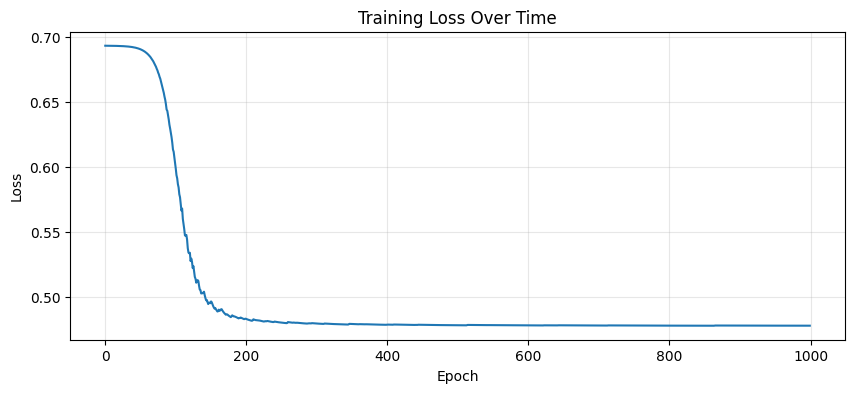

In [6]:
# visualizing
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# checking the weights
print("\n- - - Learned Weights- - - ")
print(f"W1 (Input → Hidden):\n{nn.W1}")
print(f"b1:\n{nn.b1}")
print(f"W2 (Hidden → Output):\n{nn.W2}")
print(f"b2:\n{nn.b2}")


- - - Learned Weights- - - 
W1 (Input → Hidden):
[[-1.16136707 -0.03391161 -1.12112823 -1.85220093]
 [ 1.17013554 -0.00793595  1.12272254  1.74124925]]
b1:
[[-0.04699676  0.         -0.05418971 -0.08384984]]
W2 (Hidden → Output):
[[ 1.59284518e+00]
 [-1.53666243e-03]
 [ 1.53062753e+00]
 [ 2.46006834e+00]]
b2:
[[-0.69142214]]
